Zadanie 1

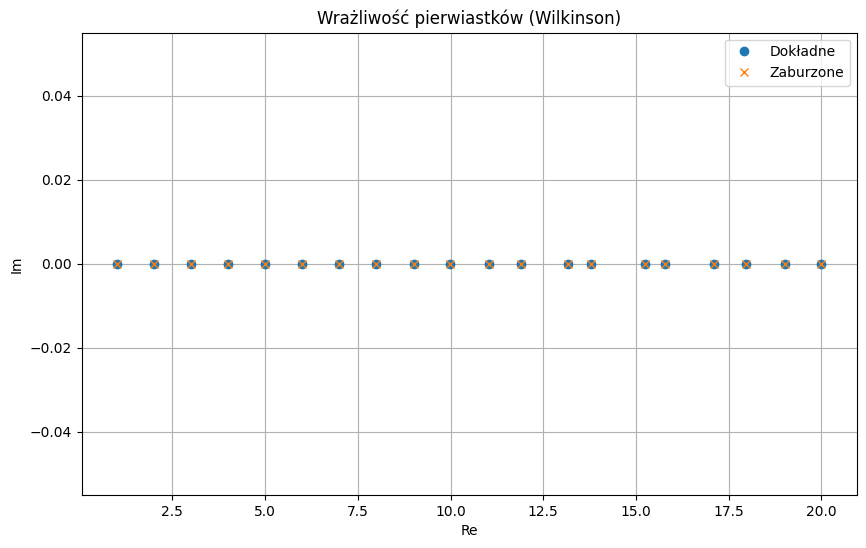

Wniosek: problem może być bardzo źle uwarunkowany.


In [6]:
from numpy.polynomial import Polynomial
import numpy as np
import matplotlib.pyplot as plt

# Wielomian Wilkinsona: (x-1)(x-2)...(x-20)
roots = np.arange(1, 21)
p = Polynomial.fromroots(roots)

# Pierwiastki dokładne
exact_roots = p.roots()

# Zaburzamy współczynnik (mała zmiana)
p_perturbed = Polynomial(p.coef.copy())
p_perturbed.coef[1] += 1e-7

perturbed_roots = p_perturbed.roots()

# Wykres porównania
plt.figure(figsize=(10, 6))
plt.plot(exact_roots.real, exact_roots.imag, 'o', label="Dokładne")
plt.plot(perturbed_roots.real, perturbed_roots.imag, 'x', label="Zaburzone")
plt.legend()
plt.title("Wrażliwość pierwiastków (Wilkinson)")
plt.xlabel("Re")
plt.ylabel("Im")
plt.grid()
plt.show()
print("Wniosek: problem może być bardzo źle uwarunkowany.")

Zadanie 1 (Mejsca zerowe)

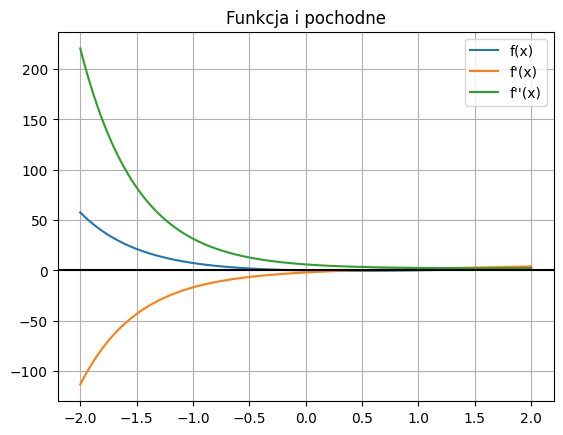

Z wykresu 2 miejsca zerowe


In [8]:
def f(x):
    return np.exp(-2*x) + x**2 - 1

def df(x):
    return -2*np.exp(-2*x) + 2*x

def ddf(x):
    return 4*np.exp(-2*x) + 2

x = np.linspace(-2, 2, 400)

plt.plot(x, f(x), label="f(x)")
plt.plot(x, df(x), label="f'(x)")
plt.plot(x, ddf(x), label="f''(x)")
plt.axhline(0, color='black')

plt.legend()
plt.grid()
plt.title("Funkcja i pochodne")
plt.show()
print("Z wykresu 2 miejsca zerowe")

Zadanie 2 (Implementacja metod)

In [10]:
#1 Bisekcja 

def bisection(f, a, b, eps=1e-6, max_iter=1000):
    it = 0
    while (b - a)/2 > eps and it < max_iter:
        c = (a + b)/2
        if f(c) == 0:
            return c, it
        elif f(a)*f(c) < 0:
            b = c
        else:
            a = c
        it += 1
    return (a + b)/2, it

#2 Newton-Raphson

def newton(f, df, x0, eps=1e-6, max_iter=1000):
    x = x0
    it = 0
    while it < max_iter:
        x_new = x - f(x)/df(x)
        if abs(x_new - x) < eps:
            return x_new, it
        x = x_new
        it += 1
    return x, it

#3 Siecznych

def secant(f, x0, x1, eps=1e-6, max_iter=1000):
    it = 0
    while it < max_iter:
        if abs(f(x1) - f(x0)) < 1e-12:
            break
        x2 = x1 - f(x1)*(x1 - x0)/(f(x1) - f(x0))
        if abs(x2 - x1) < eps:
            return x2, it
        x0, x1 = x1, x2
        it += 1
    return x1, it

Zadanie 3

In [13]:
eps = 1e-6

# Bisekcja
root_bis, it_bis = bisection(f, -1, 1)

# Newton
root_new, it_new = newton(f, df, 0.5)

# Sieczne
root_sec, it_sec = secant(f, -1, 1)

print("Bisekcja:", root_bis, "iteracje:", it_bis)
print("Newton:", root_new, "iteracje:", it_new)
print("Sieczne:", root_sec, "iteracje:", it_sec)
print("Typowy wynik: \n Newton: najszybszy \n Sieczne: trochę wolniejsze \n Bisekcja: najwolniejsza, ale stabilna")

Bisekcja: 0.0 iteracje: 0
Newton: 0.916562583105698 iteracje: 6
Sieczne: 0.9165625831057073 iteracje: 5
Typowy wynik: 
 Newton: najszybszy 
 Sieczne: trochę wolniejsze 
 Bisekcja: najwolniejsza, ale stabilna


Zadanie 4

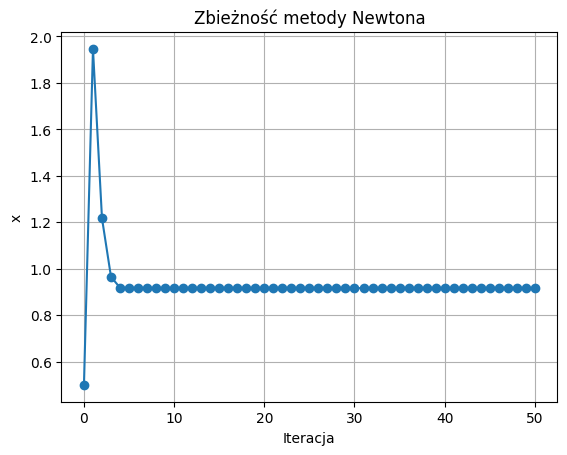

Analiza: 
 Metoda Jacobiego zbiega najwolniej — spadek błędu jest łagodny 
 Metoda Gaussa-Seidela zbiega szybciej — wykorzystuje aktualizowane wartości 
 Metoda SOR (dla ω > 1) przyspiesza zbieżność najbardziej


In [16]:
def newton_history(f, df, x0, eps=1e-6, max_iter=50):
    x = x0
    history = [x]
    for _ in range(max_iter):
        x = x - f(x)/df(x)
        history.append(x)
    return history

hist = newton_history(f, df, 0.5)

plt.plot(hist, marker='o')
plt.title("Zbieżność metody Newtona")
plt.xlabel("Iteracja")
plt.ylabel("x")
plt.grid()
plt.show()
print("Analiza: \n Metoda Jacobiego zbiega najwolniej — spadek błędu jest łagodny \n Metoda Gaussa-Seidela zbiega szybciej — wykorzystuje aktualizowane wartości \n Metoda SOR (dla ω > 1) przyspiesza zbieżność najbardziej")